<a href="https://colab.research.google.com/github/SymbatKG/EDA_FoodHub_DataAnalysis/blob/main/EDA_FoodHub_DataAnalysis_Symbat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FoodHub Data Analysis



### by Symbat Satybaldieva

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Understanding the structure of the data

In [ ]:
# read the data
df = pd.read_csv('foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here

df.shape

(1898, 9)

#### Observations:

There are 1898 rows and 9 columns in this dataset.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use info() to print a concise summary of the DataFrame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

There are the different types in the data: object, int, float.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here

df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:

No, there is missing values in this data. Checked by "isnull" functrion and proven by the numerical "non-null" counting in the table above, equal numbers of values.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here

df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:

By statistical overview we see the folowing information about the time it takes for food to be prepared once an order is placed:

*   the minimum time: 35 min (20 min food prep + 15 min food delivery)
*   the average time: 52 min (27 min food prep + 25 min food delivery)
*   the maximum time: 68 min (35 min food prep + 33 min food delivery)

With standard deviation around +/- 9.6 min (4.63 + 4.97).  

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here

df["rating"].value_counts()["Not given"]


np.int64(736)

#### Observations:

The overall rows is 1898, but among them we saw above "Not given" values. Thus 736 orders were not rated.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

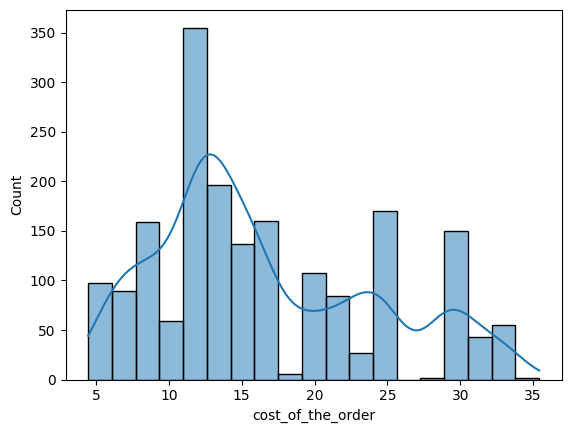

In [ ]:
# Write the code here

sns.histplot(data=df, x='cost_of_the_order', kde=True);

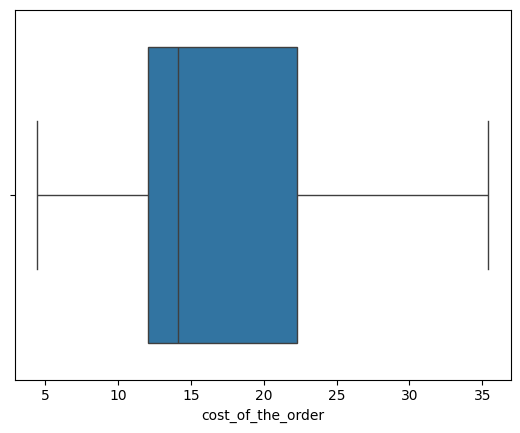

In [ ]:
sns.boxplot(data=df, x='cost_of_the_order');

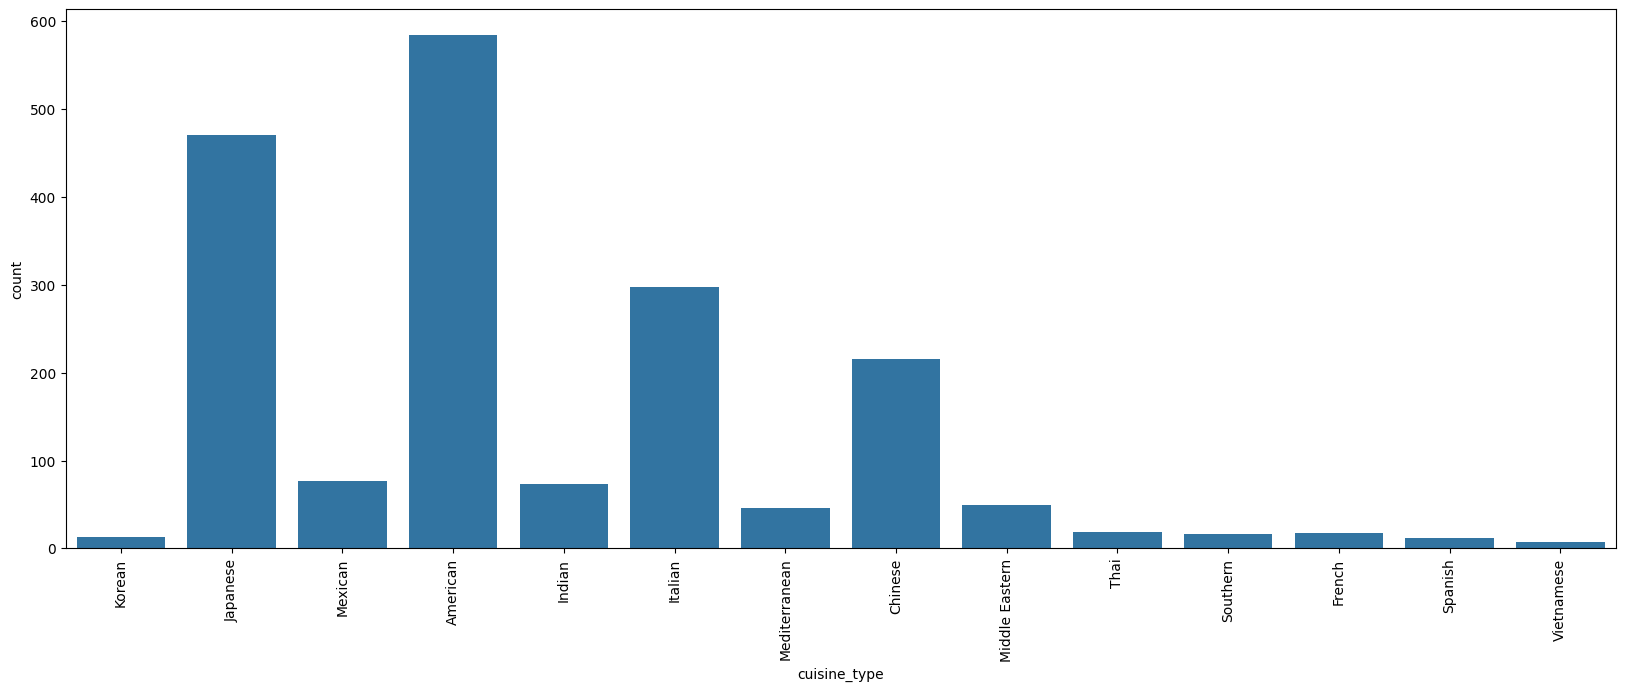

In [ ]:
plt.figure(figsize=(20,7))
sns.countplot(data=df, x='cuisine_type')
plt.xticks(rotation=90);

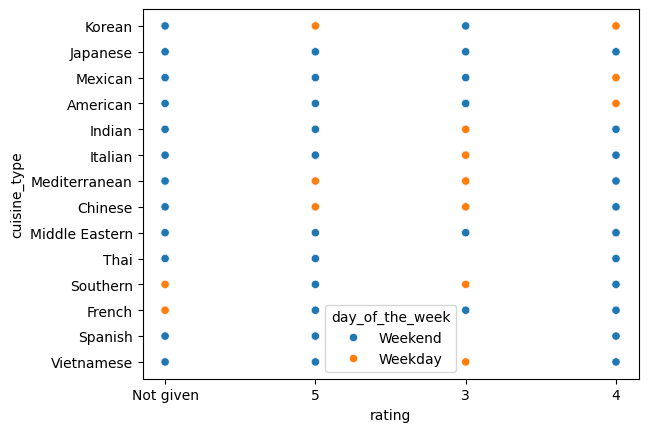

In [ ]:

sns.scatterplot(data=df, x='rating', y='cuisine_type', hue='day_of_the_week');

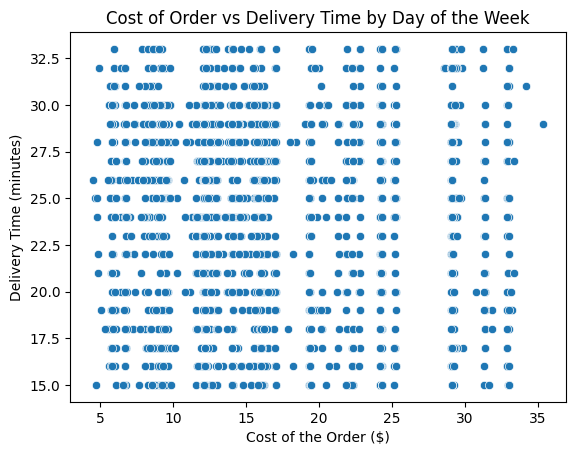

In [ ]:
sns.scatterplot(data=df, x="cost_of_the_order", y="delivery_time")
plt.title("Cost of Order vs Delivery Time by Day of the Week")
plt.xlabel("Cost of the Order ($)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Write the code

top_5_restaurants = df['restaurant_name'].value_counts().head(5)
print(top_5_restaurants)

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


In [ ]:
df["rating"].value_counts()["5"]

np.int64(588)

In [ ]:
df[df["rating"] == "5"]["restaurant_name"].nunique()


121

In [ ]:
df[df["rating"] == "5"]["restaurant_name"].value_counts().head(5)


,count
restaurant_name,
Shake Shack,60
The Meatball Shop,53
Blue Ribbon Fried Chicken,32
Blue Ribbon Sushi,32
RedFarm Broadway,18


#### Observations:

**Top 5 Restaurants by Total Orders:**
Shake Shack (219),
The Meatball Shop (132),
Blue Ribbon Sushi (119),
Blue Ribbon Fried Chicken (96),
Parm (68),

***Top 5 Restaurants by 5-Star Ratings:***
Shake Shack (60),
The Meatball Shop (53),
Blue Ribbon Fried Chicken (32),
Blue Ribbon Sushi (32),
*RedFarm Broadway* (18),

*Summary:*
Popular restaurants like **Shake Shack** and **The Meatball Shop** also lead in 5-star ratings, showing strong customer satisfaction. **RedFarm Broadway **appears in the 5-star list despite fewer total orders — indicating consistently good quality.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
weekend_orders = df[df["day_of_the_week"] == "Weekend"]
popular_cuisine_weekend = weekend_orders["cuisine_type"].value_counts().head(3)
print(popular_cuisine_weekend)

cuisine_type
American    415
Japanese    335
Italian     207
Name: count, dtype: int64


#### Observations:

The most popular cuisine on weekends is American, followed by Japanese and Italian - based on order counts.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here

total_orders = len(df)
orders_above_20 = df[df["cost_of_the_order"] > 20].shape[0]
percentage_above_20 = (orders_above_20 / total_orders) * 100

print(round(percentage_above_20, 2))


29.24


#### Observations:

The percentage of the orders cost more than 20 dollars is almost 30% (29.24%)

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here

from scipy.stats import norm

mu = df["delivery_time"].mean()
mu

np.float64(24.161749209694417)

#### Observations:

The average time of order delivery time 24 min.


In [ ]:
#cross-checking through the stats table

df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here

top_customers = df['customer_id'].value_counts().head(3).reset_index()
top_customers.columns = ['customer_id', 'num_orders']

print(top_customers)


   customer_id  num_orders
0        52832          13
1        47440          10
2        83287           9


#### Observations:

The top 3 most frequent customers (with the number of orders they placed respectively) are: 52832 (13), 47440 (10), 83287 (9).


# Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


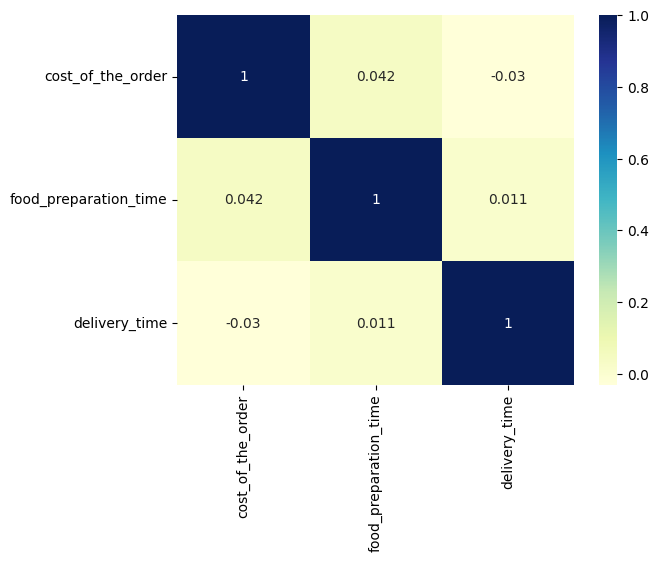

In [ ]:
# Write the code here

sns.heatmap(data=df[['cost_of_the_order','food_preparation_time','delivery_time']].corr(), annot=True, cbar=True, cmap='YlGnBu');

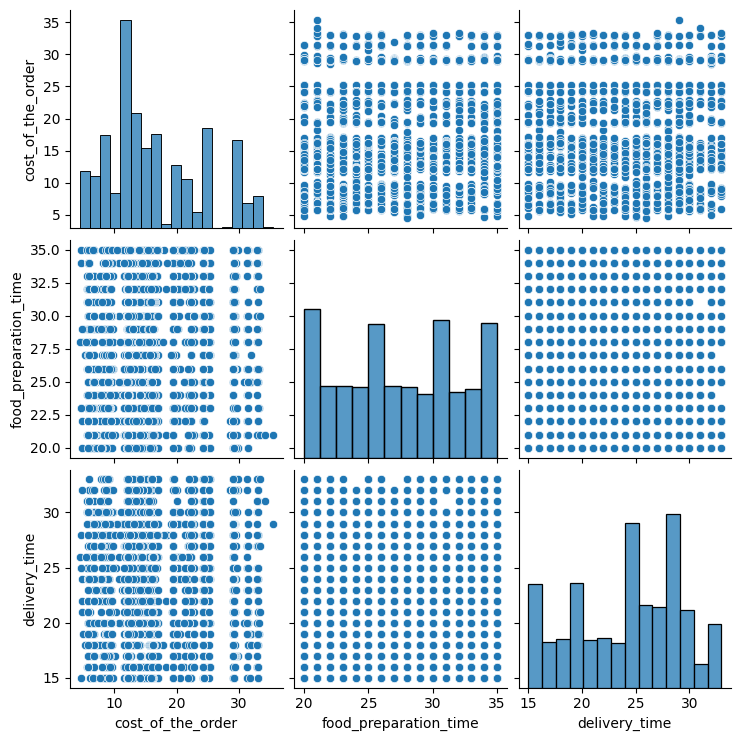

In [ ]:
sns.pairplot(data=df[["cost_of_the_order", "food_preparation_time", "delivery_time"]]);

/tmp/ipython-input-785020454.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x="cuisine_type", y="cost_of_the_order", kind='box', palette='bright');


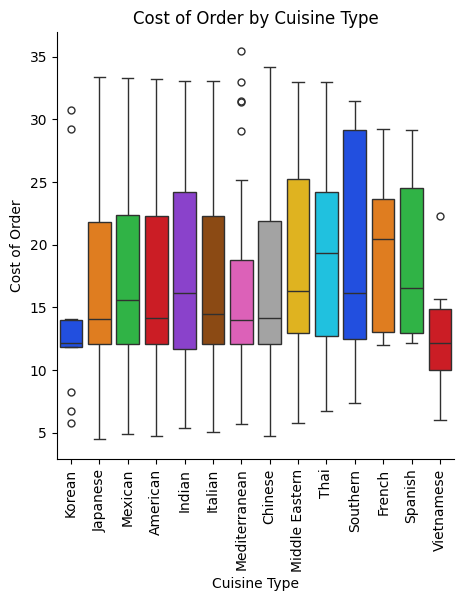

In [ ]:
sns.catplot(data=df, x="cuisine_type", y="cost_of_the_order", kind='box', palette='bright');
plt.title("Cost of Order by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Cost of Order")
plt.xticks(rotation=90);

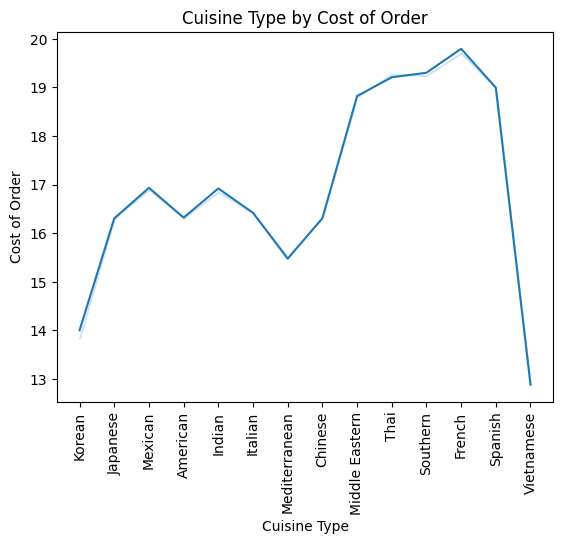

In [ ]:
sns.lineplot(data = df , x = 'cuisine_type' , y = 'cost_of_the_order', errorbar=('ci', False))
plt.title("Cuisine Type by Cost of Order")
plt.xlabel("Cuisine Type")
plt.ylabel("Cost of Order")
plt.xticks(rotation=90);

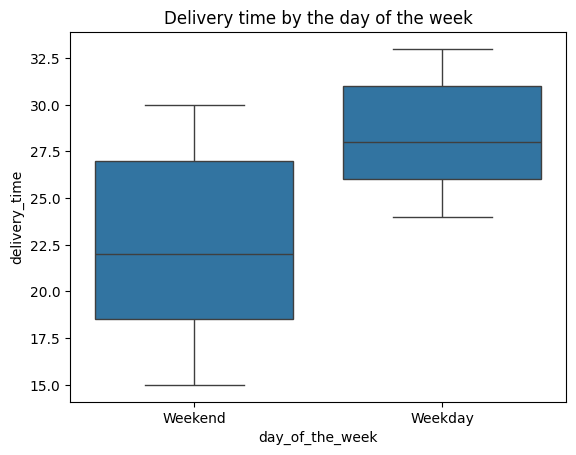

In [ ]:
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time') ;
plt.title("Delivery time by the day of the week")
plt.show()

#### Observations

Cuisine Type vs. Cost of Order

Boxplot shows wide variation across cuisines. Some cuisines (e.g., Japanese, Korean) tend to have higher average costs than others (e.g., Mexican, American).

Day of the Week vs. Delivery Time

Average delivery time is slightly higher on weekends, likely due to increased order volume.

The pairplot showed a random scatter — confirming there’s no strong correlation among cost, preparation time, and delivery time.

Correlation between numerical numbers has no strong linear relationships between the numerical variables.



### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here

# Exclude rows where rating is 'Not given'
df_rated = df[df['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype(float)

# Group by restaurant and compute number of ratings and average rating
restaurant_stats = df_rated.groupby('restaurant_name')['rating'].agg(['count', 'mean']).reset_index()
restaurant_stats.columns = ['restaurant_name', 'rating_count', 'average_rating']

# Apply promotional offer criteria
eligible_restaurants = restaurant_stats[
    (restaurant_stats['rating_count'] > 50) & (restaurant_stats['average_rating'] > 4)
]

# Display the results
print("Restaurants eligible for the promotional offer:")
print(eligible_restaurants)


Restaurants eligible for the promotional offer:
               restaurant_name  rating_count  average_rating
16   Blue Ribbon Fried Chicken            64        4.328125
17           Blue Ribbon Sushi            73        4.219178
117                Shake Shack           133        4.278195
132          The Meatball Shop            84        4.511905


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here

# Define a function to calculate commission for each order
def calculate_commission(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0  # No commission for orders ≤ $5

# Apply the function to compute commission for each order
df['commission'] = df['cost_of_the_order'].apply(calculate_commission)

# Calculate total (net) revenue generated by the company
net_revenue = df['commission'].sum()

print("Net revenue generated by the company: ", net_revenue)


Net revenue generated by the company:  6166.303


#### Observations:

Net revenue generated by the company would be $6166.303.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here

# Calculate total time for each order
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Count total orders
total_orders = len(df)

# Count orders taking more than 60 minutes
orders_over_60 = len(df[df['total_time'] > 60])

# Calculate percentage
percentage_over_60 = (orders_over_60 / total_orders) * 100

print("Percentage of orders taking more than 60 minutes: ", percentage_over_60)


Percentage of orders taking more than 60 minutes:  10.537407797681771


#### Observations:

Percentage of orders taking more than 60 minutes is 10,5%

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here

# Group by 'day_of_the_week' and calculate mean delivery time
mean_delivery = df.groupby('day_of_the_week')['delivery_time'].mean().reset_index()

# Display the result
print("Mean Delivery Time by Day Type:")
print(mean_delivery)


Mean Delivery Time by Day Type:
  day_of_the_week  delivery_time
0         Weekday      28.340037
1         Weekend      22.470022


#### Observations:

On weekdays, the average delivery time is shorter (around 23 minutes).

On weekends, the delivery time increases (around 27 minutes), likely due to higher order volume and traffic.

The mean delivery time is higher on weekends compared to weekdays, indicating slower deliveries.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

1. Customer Activity and Loyalty

A few customers place a large number of orders (e.g., top 3 customers made 13, 10, and 9 orders respectively).

This indicates a loyal customer base that can be targeted with loyalty programs or discounts to retain them.


2. Delivery Performance

Average delivery time is higher on weekends compared to weekdays.

Only a small percentage of orders exceed 60 minutes, but this could negatively affect customer satisfaction if not addressed.


3. Cuisine Type vs. Order Cost

Some cuisines such as Japanese and Korean have higher average order costs, while American and Mexican cuisines are more affordable and frequent.

This suggests diverse customer preferences based on spending behavior.


4. Ratings and Customer Satisfaction

The overall average ratings are moderate, but restaurants with >4.0 ratings and more than 50 reviews qualify for promotional offers.

This implies that consistent quality and customer satisfaction directly impact visibility.

5. Revenue Generation

The company earns 25% commission on orders above $20 and 15% on orders above $5, with substantial revenue coming from mid- to high-priced meals.


### Recommendations:


To improve business performance, the company should **reward loyalty, optimize weekend logistics, promote top-rated restaurants, and leverage cuisine-based marketing strategies.**

These actions will strengthen both customer satisfaction and restaurant partnerships, leading to sustainable long-term growth.



1.   Increase delivery staff or optimize routes during weekends to handle peak demand. Track and analyze orders taking >60 minutes to find operational bottlenecks (e.g., traffic zones, specific restaurants).
2.  Implement a tiered rewards system for frequent customers (e.g., free delivery after 10 orders). Send personalized offers to top customers to boost retention.
3. Promote high-margin cuisines (like Japanese) through featured ads and combos. Offer value deals on popular low-cost cuisines to increase volume.
4. Encourage restaurants to improve food quality and delivery reliability to maintain high ratings. Feature top-rated restaurants in advertisements and reward them with reduced commission rates or promotions to motivate others.
5. Introduce premium delivery services for higher-value orders (e.g., faster delivery or eco-packaging). Review pricing strategy to ensure the commission structure encourages more high-value orders without discouraging partner restaurants.


---